In [ ]:
from collections import defaultdict
import json
from torch.utils.data import Dataset, DataLoader
import os, sys, torch, random
from pathlib import Path
import numpy as np
from torchvision import tv_tensors                                      
from utils.utils import (
    crop_ultrasound_pil,
    extract_bbox_ultrasound_cv2,
    organ_to_class_dict,
    dataset_to_organ_dict,
    dataset_for_classification,
    dataset_for_segmentation,
    multi_cls_labels_dict,
    resize_pad,
)
from PIL import Image
from torchvision.transforms.v2.functional import pil_to_tensor, center_crop, to_pil_image
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image
from tqdm import tqdm 
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import numpy as np
from data_classes.datasets import USdatasetOmni

In [ ]:
from utils.utils import get_sft_transforms
from utils.paths import *


dataset = USdatasetOmni(
    base_dir=DATA_DIR,
    split="val_cls",
    transforms=get_sft_transforms(train=False),
    out_size=512,
    data_type="segmentation",
    ccl_crop=False,
    keep_aspect_ratio=True,
    self_norm=True, 
    skip_dataset="Testicle",
    id_dropout=0.0
)
len(dataset)

In [ ]:
x = dataset.__getitem__(10)['pixel_values']
x_min = x.min()
x_max = x.max()

# 2. Scale
# eps handles the edge case where x_max == x_min
eps = 1e-7 
x_scaled = (x - x_min) / (x_max - x_min + eps)
to_pil_image(x_scaled)

In [ ]:
from nets.unet_attn import canonicalize_mask_batch_normalized, canonicalize_mask_batch
from torchvision.transforms.functional import to_pil_image
mask = dataset.__getitem__(10)['masks']
to_pil_image(mask)

In [ ]:
to_pil_image(canonicalize_mask_batch_normalized(mask.unsqueeze(0), canon_res=128))

In [ ]:
to_pil_image(canonicalize_mask_batch(mask.unsqueeze(0), canon_res=128))


In [ ]:
from argparse import Namespace
from collections import defaultdict
from copy import deepcopy
from transformers.trainer import Trainer
from transformers.training_args import TrainingArguments
from data_classes.datasets import USdatasetOmni
from torchvision.transforms import InterpolationMode, v2
import torch, wandb, random
from sklearn.metrics import accuracy_score
from nets.cls_net import OmniClsCBAM
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from utils.paths import DATA_DIR
from utils.utils import organ_to_class_dict, multi_cls_labels_dict, generate_run_hash
import numpy as np
from utils.utils import (
    get_sft_transforms,
    compute_dsc,
    class_to_organ_dict,
    compute_nsd,
    mask_overlap_visualization,
)
from utils.stratified_splits import build_train_val_datasets
from utils.paths import *
from torch.utils.data import Subset, ConcatDataset


In [ ]:
from segment_anything import sam_model_registry
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)
print(sum([p.numel() for p in sam_model.parameters()]))
model = MedSAMPrompt(
            image_encoder=deepcopy(sam_model.image_encoder),
            mask_decoder=deepcopy(sam_model.mask_decoder),
            prompt_encoder=deepcopy(sam_model.prompt_encoder),
            predict_bboxes=True,
            freeze_image_encoder=0,
        )
model.cuda()

In [ ]:
training_args = TrainingArguments(
    output_dir="./loggings/debug",
    # num_train_epochs=args.epochs,
    max_steps=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    seed=42,
    save_strategy="steps",
    eval_strategy="steps",
    save_steps=int(1 / 100),
    eval_steps=int(1 / 100),
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    report_to=None,
    dataloader_num_workers=8,
    logging_steps=10,
    log_level="info",
    eval_accumulation_steps=100,
    optim="adamw_torch",
    learning_rate=1e-3,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    gradient_accumulation_steps=2,
    # fp16=True,
    # push_to_hub=False,
)

In [ ]:
from safetensors.torch import load_file
from utils.distill_enc import apply_lora_to_encoder
# peft_model_dict = torch.load("/media/raid0/US_FiLMUNet/loggings/peft_unet4_2/final_model_lora.pth")
model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=8,
    size=32,
    depth=5,
    film_start=0,
    use_film=True,
    distill=True
)
state_dict = load_file("/media/disk1/US_FiLMUNet/checkpoints/unet5/model.safetensors")
model.load_state_dict(state_dict, strict=False)

model.cuda()

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def compute_erf(model, input_size=(1, 3, 512, 512), device='cuda'):
    """
    Compute effective receptive field using gradient method
    """
    model.eval()
    
    # Create input with requires_grad
    x = torch.randn(input_size, requires_grad=True, device=device)
    
    # Forward pass
    # output = model(x)

    output = model.forward(
        pixel_values=x.cuda(),
        # masks=data["masks"].unsqueeze(0).repeat(4,1,1).cuda(),
        organ_id=torch.Tensor([0]).long().cuda(),
    )['logits']
    # Get center position of output
    if len(output.shape) == 4:  # For CNNs: (B, C, H, W)
        center_h, center_w = output.shape[2] // 2, output.shape[3] // 2
        target = output[0, :, center_h, center_w].sum()
    else:  # For fully connected
        target = output[0].sum()
    
    # Backward pass
    target.backward()
    
    # Get gradient magnitude
    erf = x.grad[0].abs().sum(dim=0).cpu().numpy()
    
    return erf

def compute_erf_averaged(model, input_size=(1, 3, 512, 512), 
                         device='cuda', n_samples=100):
    model.eval()
    erf_sum = None
    
    for i in range(n_samples):
        x = torch.randn(input_size, requires_grad=True, device=device)
        output = model.forward(
            pixel_values=x.cuda(),
            # masks=data["masks"].unsqueeze(0).repeat(4,1,1).cuda(),
            organ_id=torch.Tensor([0]).long().cuda(),
        )['logits']
        
        # Center pixel
        if len(output.shape) == 4:
            center_h, center_w = output.shape[2] // 2, output.shape[3] // 2
            target = output[0, :, center_h, center_w].sum()
        else:
            target = output[0].sum()
        
        target.backward()
        
        erf = x.grad[0].abs().sum(dim=0).cpu().numpy()
        
        if erf_sum is None:
            erf_sum = erf
        else:
            erf_sum += erf
    
    return erf_sum / n_samples
# Visualize
erf = compute_erf_averaged(model)
plt.imshow(erf, cmap='hot')
plt.colorbar()
plt.title('Effective Receptive Field')
plt.show()

In [ ]:
from train.segm_train import UNet2DFiLM
model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=8,
    size=32,
    depth=4,
    film_start=0,
    use_film=True,
    distill=False
)
model.cuda()
print(sum([p.numel() for p in model.parameters()]))
from safetensors.torch import load_file

state_dict = load_file("/work/phd_ultrasounds/UUSIC_new/checkpoints/unet4/model.safetensors")
model.load_state_dict(state_dict)

In [ ]:
from nets.unet_attn import UNet2DAttn
from safetensors.torch import load_file
model = UNet2DAttn(
    in_channels=3,
    num_classes=1,
    n_organs=10,
    size=32,
    depth=4,
    attn_start=0,      # Start attention from first level
    use_attn=True,     # Enable attention
    img_size=512,      # Input image size
    patch_size=8,     # 16×16 patches → 256 patches total
    emb_dim=768,       # Embedding dimension
    n_heads=8,          # Number of attention heads,
    # n_transformer_layers = 12,
    distill = 1,
    use_dwt=True,
    wavelet='haar',
    # dwt_bands=['HH'],
    use_shape = False,
    shape_res=64,
    # distill_unet=True
)
model.cuda()
print(sum([p.numel() for n, p in model.named_parameters() if 'distill_model' not in n]))
# state_dict = load_file("./loggings/6c4b0a465d57/checkpoint-8000/model.safetensors")
# state_dict = {k: v for k, v in state_dict.items() if 'distill' not in k } #remove distiller, is useless
# load_results = model.load_state_dict(state_dict, strict=False)

In [ ]:
tmp = torch.sigmoid(model.shared_attn.shape_proj(model.shared_attn.shape_embed.weight.clone().detach()).reshape(11, 32, 32))

In [ ]:
from torchvision.transforms.functional import to_pil_image

to_pil_image((tmp[1]>0.5).to(torch.float32))

In [ ]:
from nets.unet_attn import FiLMLayer
print("--- FiLM/Attention Injection Points ---")
for name, module in model.named_modules():
    if isinstance(module, FiLMLayer):
        # This shows the path to every active modulation point
        print(f"Conditioning injected at: {name}")

In [ ]:
model.cuda()
print(sum([p.numel() for p in model.parameters()]))
from safetensors.torch import load_file

state_dict = load_file("/media/raid0/US_FiLMUNet/loggings/dd162636aa38/checkpoint-8400/model.safetensors")
model.load_state_dict(state_dict, strict = False)

In [ ]:
sd = model.state_dict()
seen = {}
for k, v in sd.items():
    ptr = v.storage().data_ptr() if v.is_cuda is False else v.untyped_storage().data_ptr()
    seen.setdefault(ptr, []).append(k)

shared = {ptr:names for ptr,names in seen.items() if len(names) > 1}
print("num shared storages:", len(shared))
for ptr, names in list(shared.items())[:10]:
    print(names)


In [ ]:
from torch import nn
import torch

updated = 0
with torch.no_grad():
    for name, module in model.named_modules():
        # your FiLM2d has attribute .embed which is nn.Embedding
        # print(name)
        if hasattr(module, "patch_embed"):
            #  and isinstance(getattr(module, "embed"), nn.Embedding)
            # emb: nn.Embedding = module.embed
            # W = emb.weight  # [num_embeddings, emb_dim]
            # if W.shape[0] < 10:
            #     raise ValueError(f"{name}.embed has {W.shape[0]} rows (<10); can't set rows 8 and 9.")
            # mean_0_7 = W[0:8].mean(dim=0)   # [emb_dim]
            # W[8].copy_(mean_0_7)
            # W[9].copy_(mean_0_7)
            updated += 1
print(updated)

In [ ]:
data["masks"].shape

In [ ]:
to_pil_image(data['pixel_values_medsam'])

In [ ]:
data = dataset.__getitem__(100)
data.keys()
model.eval()
with torch.no_grad():
    out = model.forward(
        pixel_values=data["pixel_values"].unsqueeze(0).repeat(4,1,1,1).cuda(),
        masks=data["masks"].unsqueeze(0).repeat(4,1,1).cuda(),
        organ_id=torch.Tensor([-1]).long().repeat(4).cuda(),
        pixel_values_medsam=data["pixel_values_medsam"].unsqueeze(0).repeat(4,1,1,1).cuda()
    )
out['loss']

In [ ]:
out.keys()

In [ ]:
from train.segm_train import compute_metrics, CustomTrainerWithSampler



In [ ]:
enc = model.encode(data['pixel_values'].unsqueeze(0).cuda(), torch.Tensor([data['organ_id']]).long().cuda())[0]

In [ ]:
from segment_anything import sam_model_registry
from copy import deepcopy
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from safetensors.torch import load_file
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)

model = MedSAM(
    image_encoder=deepcopy(sam_model.image_encoder),
    mask_decoder=deepcopy(sam_model.mask_decoder),
    prompt_encoder=deepcopy(sam_model.prompt_encoder),
    predict_bboxes=True,
    freeze_image_encoder=0,
)
state_dict = load_file(
    "/work/phd_ultrasounds/UUSIC_new/checkpoints/medsam_unfreezed/model.safetensors"
)
model.load_state_dict(state_dict)
load_result = model.load_state_dict(state_dict)
print(load_result)
model.eval()
model = model.cuda()

In [ ]:
with torch.no_grad():
    image_embedding = model.image_encoder(data['pixel_values'].unsqueeze(0).cuda()) 
    image_embedding

In [ ]:
with torch.no_grad():
    image_pe = model.prompt_encoder.get_dense_pe()
            # Decode mask
    low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embedding,  # (B, 256, 64, 64)
            image_pe=image_pe,  # (1, 256, 64, 64)
            sparse_prompt_embeddings=model.learned_sparse_embeddings,  # (B, 2, 256)
            dense_prompt_embeddings=model.learned_dense_embeddings,  # (B, 256, 64, 64)
            multimask_output=False,
        ) 

In [ ]:
wandb.login()
wandb.init(
    entity='nmorelli-unimore',
    project='uusic_segm2',
    name='unet5_onpublic',
    # config=args,
    # resume = True,
    # id = 'wp55lzxe'
)

In [ ]:
tmp.std()

In [ ]:
model.shared_attn.organ_embed.weight[-1].std()

In [ ]:
from torch import  nn

with torch.no_grad():
    nn.init.normal_(
        model.shared_attn.organ_embed.weight,
        mean=0.0,
        std=0.02
    )


In [ ]:
nn.init.normal_(self.organ_embed.weight, mean=0, std=0.02)

In [ ]:
from train.segm_train import compute_metrics, CustomTrainerWithSampler

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        eval_dataset=dataset,
        compute_metrics=compute_metrics,
        # train_sampler=train_sampler,
    )

In [ ]:
metrics = trainer.evaluate()

In [ ]:
len(dataset)

In [ ]:
predictions[2]

In [ ]:
data = dataset.__getitem__(0)
data.keys()
out = model(pixel_values = data['pixel_values'].unsqueeze(0).cuda(), organ_id = data['organ_id'].clone().cuda())

In [ ]:
out

In [ ]:
from torchvision.transforms.v2.functional import to_pil_image

to_pil_image((torch.sigmoid(out['logits']) > 0.7).to(torch.float32))

In [ ]:
history.columns

In [18]:
# !pip install wandb pandas numpy

import wandb
import numpy as np
import pandas as pd
from collections import defaultdict

api = wandb.Api()

# --- Put your runs here ---
run_paths = [
    "nmorelli-unimore/uusic_segm2/runs/549d9186e3d9",
    "nmorelli-unimore/uusic_segm2/runs/0cbf5e529167",
    "nmorelli-unimore/uusic_segm2/runs/75f7a224d214",
]

# Keyword to match (case-insensitive)
keyword = "test/dsc"

# If True: take the last logged value for each metric in each run
# If False: take the mean across steps for each run, then aggregate across runs
use_last_value = True

# -----------------------------------------------------------------------------
# 1) discover all metric names across runs that contain the keyword
metric_names = set()
for path in run_paths:
    run = api.run(path)
    # scan full history once and collect keys
    for row in run.scan_history():
        for k in row.keys():
            if isinstance(k, str) and keyword in k.lower():
                metric_names.add(k)
    # also check run.summary keys as fallback
    for k in run.summary.keys():
        if isinstance(k, str) and keyword in k.lower():
            metric_names.add(k)

metric_names = sorted(metric_names)
if not metric_names:
    raise RuntimeError(f"No metrics found containing '{keyword}' in any of the runs.")

# -----------------------------------------------------------------------------
# 2) gather per-metric values (one value per run, either final or per-run-mean)
metric_values = defaultdict(list)  # metric_name -> list of values (one per run where present)
missing_info = defaultdict(list)   # metric_name -> list of runs missing it

for path in run_paths:
    run = api.run(path)
    for metric in metric_names:
        # try to collect values from history first
        values = []
        # Use scan_history(keys=[metric]) to iterate only that metric
        try:
            for row in run.scan_history(keys=[metric]):
                if metric in row and row[metric] is not None:
                    values.append(row[metric])
        except Exception:
            # safety: if scan_history fails for a key, continue to summary fallback
            values = []
        # fallback to summary if no history values
        if len(values) == 0:
            # check run.summary (note: summary keys might be flattened)
            if metric in run.summary and run.summary[metric] is not None:
                values = [run.summary[metric]]
        
        if len(values) == 0:
            missing_info[metric].append(path)
            continue
        
        if use_last_value:
            chosen = values[-1]
        else:
            chosen = float(np.mean(values))
        
        metric_values[metric].append(float(chosen))

# -----------------------------------------------------------------------------
# 3) compute per-metric statistics across runs and make a DataFrame
rows = []
for metric in metric_names:
    vals = metric_values.get(metric, [])
    n = len(vals)
    if n == 0:
        mean = np.nan
        std = np.nan
    else:
        mean = float(np.mean(vals))
        std  = float(np.std(vals, ddof=0))   # change ddof=1 for sample std if desired
    rows.append({
        "metric": metric,
        "mean": mean,
        "std": std,
        "n_runs_with_value": n,
        "n_runs_total": len(run_paths),
        "missing_runs": missing_info.get(metric, [])
    })

summary_df = pd.DataFrame(rows).sort_values("metric").reset_index(drop=True)

# Nicely format numeric columns for printing
pd.set_option("display.precision", 6)
print("\n=== Summary per metric (aggregated across runs) ===\n")
print(summary_df[["metric", "mean", "std", "n_runs_with_value", "n_runs_total"]])

# If you want the full DataFrame including which runs were missing:
# print(summary_df.to_string())

# And if you want the raw per-run values for each metric:
raw_values_df = pd.DataFrame.from_dict(metric_values, orient="index").transpose()
print("\n=== Raw per-run final values (NaN where metric missing) ===\n")
print(raw_values_df)

# Keep summary_df and raw_values_df for later usage


=== Summary per metric (aggregated across runs) ===

                    metric      mean       std  n_runs_with_value  \
0  test/dsc_breast_luminal  0.688129  0.013658                  3   
1         test/dsc_cardiac  0.473512  0.027241                  3   
2           test/dsc_fetal  0.884243  0.009881                  3   
3          test/dsc_kidney  0.885396  0.002666                  3   
4            test/dsc_mean  0.688207  0.004485                  3   
5         test/dsc_thyroid  0.509758  0.004677                  3   
6         test/dsc_unknown  0.273300  0.015660                  3   

   n_runs_total  
0             3  
1             3  
2             3  
3             3  
4             3  
5             3  
6             3  

=== Raw per-run final values (NaN where metric missing) ===

   test/dsc_breast_luminal  test/dsc_cardiac  test/dsc_fetal  test/dsc_kidney  \
0                 0.679533          0.438018        0.897541         0.887966   
1                 0.67744

In [19]:
import numpy as np

# Your raw data
seeds_data = {
    42: {'dsc_unknown': 0.6388428807258606, 'nsd_unknown': 0.15842533111572266, 'dsc_breast_luminal': 0.7930302619934082, 'nsd_breast_luminal': 0.2397194504737854, 'dsc_cardiac': 0.7132772207260132, 'nsd_cardiac': 0.0947277843952179, 'dsc_thyroid': 0.4794170558452606, 'nsd_thyroid': 0.18377827107906342, 'dsc_fetal': 0.920651376247406, 'nsd_fetal': 0.21228614449501038, 'dsc_kidney': 0.8737871050834656, 'nsd_kidney': 0.2913077771663666},
    78: {'dsc_unknown': 0.6100956797599792, 'nsd_unknown': 0.1381506770849228, 'dsc_breast_luminal': 0.7737066745758057, 'nsd_breast_luminal': 0.23781929910182953, 'dsc_cardiac': 0.6638402938842773, 'nsd_cardiac': 0.09165605902671814, 'dsc_thyroid': 0.5244990587234497, 'nsd_thyroid': 0.20434628427028656, 'dsc_fetal': 0.918652355670929, 'nsd_fetal': 0.21734827756881714, 'dsc_kidney': 0.8670239448547363, 'nsd_kidney': 0.28302329778671265},
    123: {'dsc_unknown': 0.5569801926612854, 'nsd_unknown': 0.14488676190376282, 'dsc_breast_luminal': 0.7912393808364868, 'nsd_breast_luminal': 0.2320927083492279, 'dsc_cardiac': 0.7441726326942444, 'nsd_cardiac': 0.08500787615776062, 'dsc_thyroid': 0.47532767057418823, 'nsd_thyroid': 0.17900234460830688, 'dsc_fetal': 0.9187011122703552, 'nsd_fetal': 0.199250265955925, 'dsc_kidney': 0.8530519604682922, 'nsd_kidney': 0.2894817590713501}
}

# 1. Add mean_dsc to each dictionary (excluding 'unknown')
# We collect all values to calculate the final aggregate mean/std later
results_agg = {}

for seed, metrics in seeds_data.items():
    # Filter keys that start with 'dsc_' but are NOT 'dsc_unknown'
    dsc_values = [v for k, v in metrics.items() if k.startswith('dsc_') and k != 'dsc_unknown']
    
    # Calculate mean_dsc for this specific seed
    mean_val = np.mean(dsc_values)
    metrics['mean_dsc'] = mean_val
    
    # Store all values for final stats calculation
    for key, val in metrics.items():
        if key not in results_agg:
            results_agg[key] = []
        results_agg[key].append(val)

# 2. Compute and print Mean ± STD for each entry across all seeds
print(f"{'Metric':<20} | {'Mean ± STD (%)':<20}")
print("-" * 45)

# Sorting keys so they look organized
for key in sorted(results_agg.keys()):
    # Skip nsd (normalized surface distance) if you only care about dsc for the table
    if not key.startswith('dsc') and key != 'mean_dsc':
        continue
        
    vals = np.array(results_agg[key])
    mean_all = np.mean(vals) * 100  # Multiplying by 100 for percentage format
    std_all = np.std(vals) * 100
    
    print(f"{key:<20} | {mean_all:>6.2f} ± {std_all:>4.2f}")

Metric               | Mean ± STD (%)      
---------------------------------------------
dsc_breast_luminal   |  78.60 ± 0.87
dsc_cardiac          |  70.71 ± 3.31
dsc_fetal            |  91.93 ± 0.09
dsc_kidney           |  86.46 ± 0.86
dsc_thyroid          |  49.31 ± 2.23
dsc_unknown          |  60.20 ± 3.39
mean_dsc             |  75.40 ± 0.32


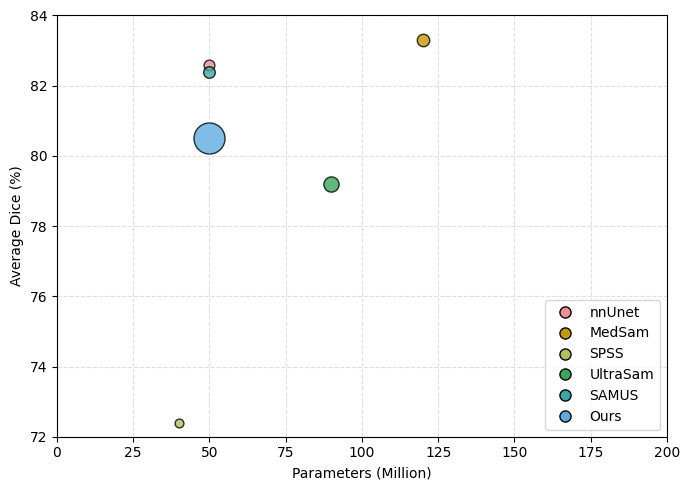

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Example data
models = [
    "nnUnet", "MedSam", "SPSS", "UltraSam",
    "SAMUS", "Ours"
]

params = [50, 120, 40, 90, 50, 50]
dice =   [68.82, 63.39, 75.40, 50, 50, 78.25,]
sizes = [60, 80, 40, 120, 70, 500, ]

colors = [
    "#f28e8e", "#c49a00", "#b5bd61", "#3ba55d",
    "#3aa6a6", "#5dade2", "#9b6bd3", "#e377c2"
]

plt.figure(figsize=(7, 5))

# Plot bubbles
for i in range(len(models)):
    plt.scatter(params[i], dice[i],
                s=sizes[i],
                color=colors[i],
                alpha=0.8,
                edgecolors='k')

# Create uniform legend markers
legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           label=models[i],
           markerfacecolor=colors[i],
           markeredgecolor='k',
           markersize=8)   # <-- fixed size for legend
    for i in range(len(models))
]

# plt.legend(handles=legend_handles, loc="center right", frameon=True)
plt.legend(handles=legend_handles,
           loc='lower right',
        #    bbox_to_anchor=(1.02, 0.5),  # move outside right
           frameon=True)

plt.tight_layout()
plt.xlabel("Parameters (Million)")
plt.ylabel("Average Dice (%)")
plt.xlim(0, 200)
plt.ylim(72, 84)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()